# 18_归一化方法-分位数缩放

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


这一个小节，和大家聊聊归一化方法方面的分位数缩放\~

### 什么是分位数缩放

分位数缩放（Quantile Scaling）是一种对数据进行归一化处理的方法，使用数据的分位数（quantile）来进行缩放，通常是根据特定的分位点（如中位数、第1四分位数、第3四分位数等）来进行变换，使得数据的分布更稳健、受异常值影响更小。

可以把它想象成这样：我不管你这堆数据最大最小是多少，我只看中间值、上下四分之一、上下四分之三这些『位置』，按照这些『位置』重新拉伸数据，把不同的数据压缩到差不多的范围。

### 举个简单的例子来理解

有一组学生的成绩：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
[30, 35, 40, 45, 50, 55, 60, 90, 100]
```

其中，**90 和 100 是两个非常高的分数**，会对最大最小值的归一化造成影响。

但是分位数缩放怎么做呢？

我们来看几个关键的「分位点」：

- **Q1**（第1四分位数）：也就是25%的位置，这里是 **40**
- **Q2**（中位数，第2四分位数）：也就是50%的位置，这里是 **50**
- **Q3**（第3四分位数）：也就是75%的位置，这里是 **60**

然后我们就可以用这些分位点来重新衡量每个数据离中位数有多远，而不是去看离最大值有多远。

### 为什么要用分位数缩放？（优点）

1. **抗异常值强**：比起最大最小缩放（min-max），分位数缩放不容易被极端值影响。
2. **更适合非正态分布的数据**：比如偏态分布，用均值和标准差不合适，但分位数很好用。
3. **稳健（robust）**：在机器学习中，稳健性强的预处理方法对模型训练更可靠。

## 数学原理

### 1. 分位数的概念回顾：

- **分位数**：将数据从小到大排序，然后按百分比位置来取值。

  - 第1四分位数（Q1）：25%的位置。
  - 中位数（Q2）：50%的位置。
  - 第3四分位数（Q3）：75%的位置。
- **四分位距（IQR）**：


$$
IQR = Q3 - Q1
$$


- 是一个衡量数据中间部分变动范围的指标。

### 2. 分位数缩放的数学公式

**常用形式：中心化 + 缩放**

我们把每个数据 $x_i$ 做如下变换：


$$
x_i' = \frac{x_i - Q2}{IQR}
$$


即：

- $Q2$ 是中位数（median），用于**中心化**
- $IQR = Q3 - Q1$，用于**缩放**（范围控制）

**有时也会写成：**


$$
x_i' = \frac{x_i - Q1}{IQR}
$$


这样就是让 Q1 变成 0，Q3 变成 1。可以理解为：

> 以 Q1 为起点、Q3 为终点，把数据映射到 0 到 1 的范围。

### 3. 解释这个公式的含义：

- **分母 IQR 是中间 50% 的跨度**，代表「数据的主干区域」。
- 把数据映射到以 Q1 \~ Q3 为基准的范围。
- 和 min-max 比起来，不会被极大值拉扯变形。
- Q2（中位数）中心化后，数据以“中位数为中心”对称展开。

## 算法流程

#### **输入**

一组原始数据 $X = [x_1, x_2, \ldots, x_n]$

#### 步骤

**第一步：排序数据**

将原始数据从小到大排序。

**第二步：计算分位点（Q1、Q2、Q3）**

$Q1$：第25%的位置

$Q2$：中位数，第50%的位置

$Q3$：第75%的位置

分位数可以通过线性插值法获得，也可以直接根据样本位置（例如第 $0.25(n+1)$ 个值）估算。

**第三步：计算 IQR**


$$
IQR = Q3 - Q1
$$


**第四步：对每个数据点进行变换**

常见两种方式：

方法A：以 Q1 开始，缩放到 [0, 1] 区间：


$$
x_i' = \frac{x_i - Q1}{IQR}
$$


- Q1 → 0，Q3 → 1

方法B：以中位数为中心，中心化处理：


$$
x_i' = \frac{x_i - Q2}{IQR}
$$


- 中位数为 0，对称展开

#### 输出

一组归一化后的数据 $X' = [x_1', x_2', \ldots, x_n']$

总结一句话：分位数缩放就是用「中位数」和「四分位距」来缩放数据，让它们更稳定、不怕离群值，还能保持中间区域的结构。

## 完整案例

在机器学习预处理中，我们常遇到这样的问题：

1. **数据分布不对称**：有的特征呈偏态分布（如指数分布），有长尾；
2. **存在离群值**：极端值会干扰均值、方差、最大最小值等；
3. **不同特征量纲相差巨大**：训练后模型可能偏向范围大的特征。

**目标**：演示使用分位数缩放，这里借助 `sklearn.preprocessing.RobustScaler` ，对有偏分布和离群值的数据进行归一化处理，并通过可视化对比「归一化前 vs. 归一化后」的效果。

下面将按代码的逻辑顺序，详细说明每一步在做什么。

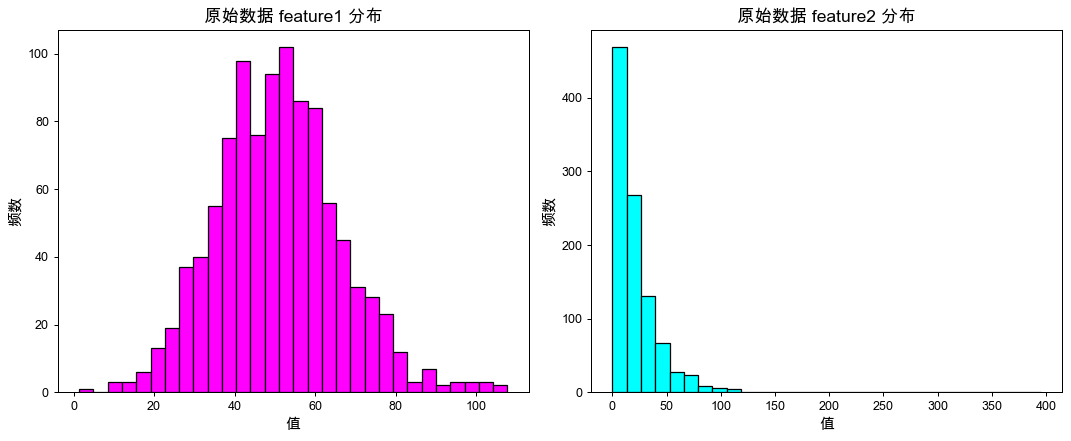

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler


# 1. 生成示例数据
np.random.seed(42)

# 正态分布数据 (均值=50, 标准差=15, 样本量=1000)
feature1 = np.random.normal(loc=50, scale=15, size=1000)

# 指数分布数据 (scale=20, 样本量=1000)
feature2 = np.random.exponential(scale=20, size=1000)

# 添加离群点
outliers1 = np.random.normal(100, 5, size=10)
outliers2 = np.random.exponential(80, size=10)

# 合并离群点
feature1 = np.concatenate([feature1, outliers1])
feature2 = np.concatenate([feature2, outliers2])

# 构建 DataFrame
df = pd.DataFrame({'feature1': feature1, 'feature2': feature2})

# 归一化前数据分布可视化
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['feature1'], bins=30, color='magenta', edgecolor='black')
plt.title('原始数据 feature1 分布', fontsize=14)
plt.xlabel('值', fontsize=12)
plt.ylabel('频数', fontsize=12)

plt.subplot(1, 2, 2)
plt.hist(df['feature2'], bins=30, color='cyan', edgecolor='black')
plt.title('原始数据 feature2 分布', fontsize=14)
plt.xlabel('值', fontsize=12)
plt.ylabel('频数', fontsize=12)

plt.tight_layout()
plt.show()

# 分位数缩放
scaler = RobustScaler(quantile_range=(25.0, 75.0))
scaled_array = scaler.fit_transform(df)
df_scaled = pd.DataFrame(scaled_array, columns=df.columns)

![原文参考图，当前结果见代码输出](attachments/img_005.png)

**RobustScaler 原理**：

- 中位数（50% 分位数）作为中心
- 四分位距（IQR = Q3 - Q1）作为缩放基准

**quantile_range=(25,75)**：默认从第 25%（Q1）到第 75%（Q3）计算 IQR

`fit_transform`：

1. 计算每列的中位数和 IQR
2. 对每个值执行 $(x - \text{median}) / \text{IQR}$

### 归一化后数据分布可视化

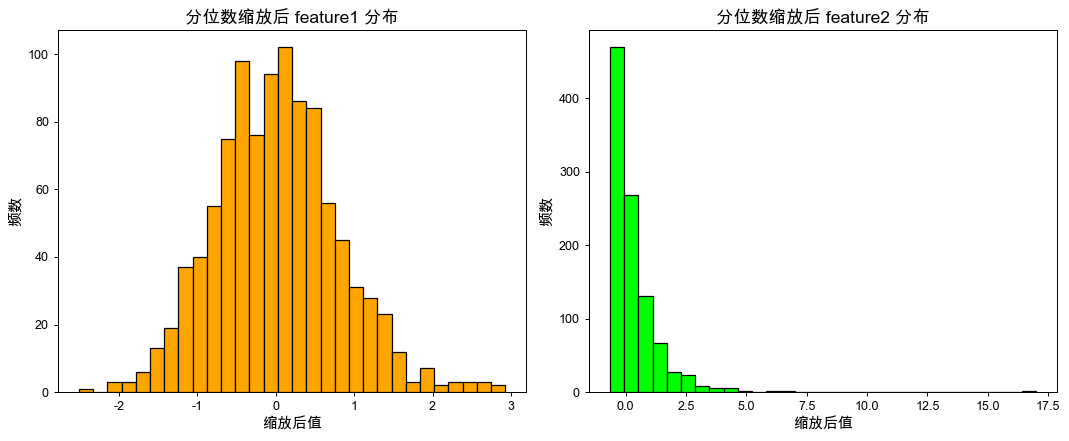

In [3]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_scaled['feature1'], bins=30, color='orange', edgecolor='black')
plt.title('分位数缩放后 feature1 分布', fontsize=14)
plt.xlabel('缩放后值', fontsize=12)
plt.ylabel('频数', fontsize=12)

plt.subplot(1, 2, 2)
plt.hist(df_scaled['feature2'], bins=30, color='lime', edgecolor='black')
plt.title('分位数缩放后 feature2 分布', fontsize=14)
plt.xlabel('缩放后值', fontsize=12)
plt.ylabel('频数', fontsize=12)

plt.tight_layout()
plt.show()

- 离群点仍存在，但其对 IQR 计算的影响被削弱
- 核心 50% 的数据被缩放到大约 [-0.5, +0.5] 或 [-1, 1] 的区间

![原文参考图，当前结果见代码输出](attachments/img_006.png)

### 缩放前后散点对比

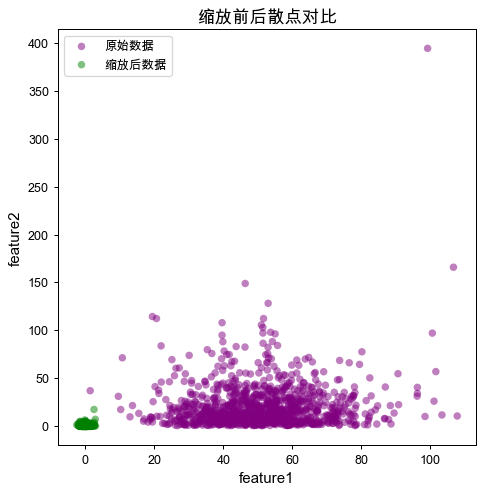

In [4]:
plt.figure(figsize=(6, 6))
plt.scatter(df['feature1'], df['feature2'],
            alpha=0.5, label='原始数据', color='purple', edgecolors='none')
plt.scatter(df_scaled['feature1'], df_scaled['feature2'],
            alpha=0.5, label='缩放后数据', color='green', edgecolors='none')
plt.title('缩放前后散点对比', fontsize=14)
plt.xlabel('feature1', fontsize=12)
plt.ylabel('feature2', fontsize=12)
plt.legend()
plt.show()

- 原始数据云图范围非常宽，离群点让整体分布拉伸
- 缩放后数据更紧凑，核心样本点更集中，离群点依旧可见但影响下降

![原文参考图，当前结果见代码输出](attachments/img_007.png)

### 分位数缩放优缺点

**优点**：

1. **鲁棒性强**：以中位数、四分位距为基准，比均值、方差对离群值更不敏感。离群点不会极大地改变缩放参数。
2. **适合偏态分布**：非对称分布（如指数分布、收入分布）中，中位数和 IQR 能更好地描述数据集中趋势和离散程度。
3. **保留稀有但有意义的极端值**：不会像截断（clipping）那样直接丢弃或压平极端值，只是降低其影响。
4. **增强模型训练稳定性**：许多机器学习算法（如线性回归、SVM、k-NN）对特征尺度敏感，分位数缩放后，模型不再“偏爱”数值巨大的特征。

**缺点**：

1. **丢失绝对量纲**：同任何归一化方法一样，缩放后失去了原始数值的物理意义，需要在结果解释时还原。
2. **不适合近似正态、无离群值的数据**：当数据已经近似正态分布、且离群值很少时，z-score（标准化）效果更好，更易满足算法对高斯分布假设。
3. **对于超大样本，计算分位数成本较高**：虽然 sklearn 已优化实现，但在分布极其复杂、样本量极大时，分位数计算比均值、方差略耗时。
4. **依赖排序/排序开销**：IQR 计算需要对数据排序，复杂度 $O(n \log n)$。

### 何时优选分位数缩放

1. **数据分布严重偏态**：收入、房价、社交网络度数等普遍呈长尾分布，用 min-max 或标准化往往失效。
2. **样本中存在显著离群值**：工业传感器故障数据、医疗检测值可能出现异常，大多数情况下这类极端值对模型训练干扰巨。
3. **对离群值有一定保留价值**：希望模型仍能学习到极端观测值的“指示意义”，但又不希望它们干扰整体尺度。
4. **对特征间相对秩序更关注**：如一些排序任务，特征的分位位置更重要，而非绝对值。

## 总结

当面对**偏态分布**、**大量离群值**的真实数据时，分位数缩放能够提供既保留数据特征、又减少异常干扰的稳定预处理，从而提升后续模型的鲁棒性与效果。